# EMSI Casablanca — Master Data & AI — Année 2025-2026
## Projet de Fin de Module : Deep Learning avec PyTorch
### Partie I : Perceptron Multicouche (MLP) (30 points)

Ce notebook est dédié à la mise en œuvre d'un Perceptron Multicouche (MLP) pour la classification binaire à l'aide de PyTorch. Nous allons explorer les concepts fondamentaux de PyTorch, préparer les données, comparer des méthodes d'initialisation des poids et évaluer les performances du modèle de manière rigoureuse.

#### Objectifs Pédagogiques :
1. Comprendre le rôle de `nn.Module` et la structure des modèles PyTorch.
2. Manipuler les tenseurs, les `Dataset` et les `DataLoader`.
3. Implémenter des boucles d'entraînement complètes avec validation et arrêt précoce (Early Stopping).
4. Étudier l'impact des stratégies d'initialisation sur la convergence.
5. Évaluer un modèle de classification à l'aide de métriques standards (Accuracy, F1, ROC AUC, Matrice de confusion).

#### Dataset Utilisé :
Le jeu de données utilisé est **Breast Cancer Wisconsin Diagnostic**, disponible directement via `sklearn.datasets.load_breast_cancer`. Il contient 569 instances avec 30 caractéristiques numériques permettant de prédire si une tumeur est maligne ou bénigne.

### Section 1 — Fondements Théoriques de PyTorch et des MLP

Avant de coder, rappelons les concepts clés de PyTorch :

- **`nn.Module`** : C'est la classe de base pour tous les modules de réseau de neurones dans PyTorch. Elle encapsule les paramètres du modèle (poids et biais) et gère leur transfert sur GPU/CPU. Elle nécessite la définition d'une méthode `forward` pour la passe avant.
- **Méthode `forward`** : Elle définit le graphe de calcul. Lorsqu'on appelle `model(X)`, PyTorch exécute en coulisses la méthode `forward(X)` tout en enregistrant les opérations pour le calcul automatique des gradients (Autograd).
- **Enregistrement des paramètres** : Tout attribut de classe héritant de `nn.Parameter` ou de `nn.Module` (comme `nn.Linear`) est automatiquement enregistré par PyTorch comme paramètre optimisable.
- **`nn.Sequential` vs Classe Personnalisée** :
  - `nn.Sequential` est une boîte noire qui enchaîne les couches séquentiellement. C'est rapide pour les architectures simples et linéaires.
  - Une classe personnalisée héritant de `nn.Module` offre une flexibilité totale, permettant des connexions résiduelles, des branchements multiples, ou le stockage d'états internes.
- **`state_dict`** : Un dictionnaire Python qui associe chaque couche à ses tenseurs de paramètres (poids et biais). Utile pour sauvegarder et charger les modèles.
- **`named_parameters`** : Un générateur qui renvoie le nom et le tenseur de chaque paramètre du réseau.
- **Gradient & Device** : Les gradients sont accumulés dans l'attribut `.grad` des tenseurs après l'appel à `.backward()`. Le calcul doit s'effectuer sur le même `device` (GPU ou CPU) pour tous les tenseurs impliqués.

#### Formules Mathématiques :
- **Couche linéaire** :  
  $$y = XW^T + b$$
  où $X$ est la matrice d'entrée de dimension $(N, D_{in})$, $W$ est la matrice des poids de dimension $(D_{out}, D_{in})$ et $b$ est le vecteur de biais de dimension $(D_{out})$.
- **Fonction d'activation ReLU** :  
  $$\text{ReLU}(z) = \max(0, z)$$
- **Propagation avant d'un MLP à 2 couches cachées** :  
  $$H_1 = \text{ReLU}(XW_1^T + b_1)$$
  $$H_2 = \text{ReLU}(H_1W_2^T + b_2)$$
  $$Y = \sigma(H_2W_3^T + b_3)$$
  où $\sigma$ représente la fonction d'activation Sigmoïde pour la classification binaire : $\sigma(z) = \frac{1}{1 + e^{-z}}$.

### Section 2 — Préparation des Données et Initialisation

Nous allons charger le dataset, diviser les données en ensembles d'entraînement, de validation et de test (70% / 15% / 15%), normaliser les caractéristiques et instancier des `DataLoader` PyTorch.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# Fixer le seed pour la reproductibilité des résultats
torch.manual_seed(42)
np.random.seed(42)

# Définition de la fonction pour sélectionner le meilleur périphérique de calcul disponible
def try_gpu():
    if torch.cuda.is_available():
        return torch.device('cuda')
    elif torch.backends.mps.is_available():
        return torch.device('mps')
    else:
        return torch.device('cpu')

device = try_gpu()
print(f"Périphérique de calcul utilisé : {device}")

# 1. Charger les données du Breast Cancer Wisconsin
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Division des données : 70% Train, 30% temporaire
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Division des 30% restants en 15% Validation et 15% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Tailles des ensembles - Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# 3. Normalisation StandardScaler entraînée sur l'ensemble d'entraînement
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 4. Conversion en tenseurs PyTorch de type float32 pour X et float32 pour y (requis pour BCELoss)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# 5. Création des TensorDatasets
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# 6. Instanciation des DataLoaders avec un batch_size de 32
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Périphérique de calcul utilisé : cpu
Tailles des ensembles - Train: 398, Val: 85, Test: 86


### Section 3 — Implémentation du MLP avec `nn.Sequential`

Nous définissons ici un premier modèle en assemblant directement les couches à l'aide de `nn.Sequential`.

In [2]:
# Définition du réseau de neurones en utilisant l'API séquentielle de PyTorch
net_seq = nn.Sequential(
    nn.Linear(30, 64),        # Première couche linéaire : 30 entrées vers 64 sorties
    nn.ReLU(),                # Fonction d'activation non-linéaire ReLU
    nn.Dropout(0.3),          # Couche Dropout pour prévenir le surapprentissage (probabilité de 30%)
    nn.Linear(64, 32),        # Deuxième couche linéaire : 64 entrées vers 32 sorties
    nn.ReLU(),                # Fonction d'activation ReLU
    nn.Linear(32, 1),         # Couche de sortie linéaire : 32 entrées vers 1 sortie (classification binaire)
    nn.Sigmoid()              # Activation sigmoïde pour projeter la sortie entre 0 et 1
)

# Transfert du modèle sur le périphérique de calcul sélectionné (CPU ou GPU)
net_seq = net_seq.to(device)
print(net_seq)

Sequential(
  (0): Linear(in_features=30, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Linear(in_features=32, out_features=1, bias=True)
  (6): Sigmoid()
)


### Section 4 — Implémentation du MLP sous forme de Classe Personnalisée

Pour plus de flexibilité, nous encapsulons la même architecture dans une classe héritant de `nn.Module`.

In [3]:
# Classe personnalisée héritant de nn.Module
class MLPClassifier(nn.Module):
    def __init__(self):
        # Initialisation de la classe parente nn.Module
        super(MLPClassifier, self).__init__()

        # Définition explicite des couches constituant le réseau
        self.fc1 = nn.Linear(30, 64)       # Première couche linéaire
        self.relu1 = nn.ReLU()             # Première activation ReLU
        self.dropout = nn.Dropout(0.3)     # Couche Dropout (30%)
        self.fc2 = nn.Linear(64, 32)       # Deuxième couche linéaire
        self.relu2 = nn.ReLU()             # Deuxième activation ReLU
        self.fc3 = nn.Linear(32, 1)        # Couche de sortie
        self.sigmoid = nn.Sigmoid()        # Activation sigmoïde finale

    def forward(self, x):
        # Définition explicite du passage avant (forward pass)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

# Instanciation du modèle personnalisé et envoi sur le périphérique disponible
model = MLPClassifier().to(device)
print(model)

MLPClassifier(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (relu1): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


### Section 5 — Inspection des Paramètres du Modèle

Nous allons inspecter les clés de notre `state_dict`, ainsi que les dimensions de chaque paramètre apprenable, et calculer le nombre total de paramètres du réseau.

In [4]:
print("=== Liste des clés du state_dict ===")
# Affichage des clés de stockage des tenseurs de poids et biais du modèle
for key in model.state_dict().keys():
    print(key)

print("\n=== Détail des Paramètres Apprenables ===")
total_params = 0
# Itération sur chaque paramètre nommé avec sa forme
for name, param in model.named_parameters():
    if param.requires_grad:
        num_params = param.numel()  # Calcul du nombre d'éléments dans le tenseur
        total_params += num_params
        print(f"Paramètre : {name} | Forme : {list(param.shape)} | Nombre : {num_params}")

print(f"\nNombre total de paramètres du modèle : {total_params}")

=== Liste des clés du state_dict ===
fc1.weight
fc1.bias
fc2.weight
fc2.bias
fc3.weight
fc3.bias

=== Détail des Paramètres Apprenables ===
Paramètre : fc1.weight | Forme : [64, 30] | Nombre : 1920
Paramètre : fc1.bias | Forme : [64] | Nombre : 64
Paramètre : fc2.weight | Forme : [32, 64] | Nombre : 2048
Paramètre : fc2.bias | Forme : [32] | Nombre : 32
Paramètre : fc3.weight | Forme : [1, 32] | Nombre : 32
Paramètre : fc3.bias | Forme : [1] | Nombre : 1

Nombre total de paramètres du modèle : 4097


### Section 6 — Étude Comparative des Stratégies d'Initialisation

L'initialisation des poids est cruciale pour la vitesse de convergence. Nous allons implémenter et comparer trois méthodes d'initialisation sur 20 epochs d'entraînement :
1. **Gaussienne** ($N(0, 0.01^2)$) : Poids très faibles, risque de disparition du gradient.
2. **Constante** (Poids = 0.5) : Brise la symétrie. Toutes les unités d'une même couche se mettront à jour de manière identique, rendant le réseau équivalent à un modèle à un seul neurone par couche.
3. **Xavier Uniforme** : Calibre la variance des poids selon le nombre d'entrées et de sorties d'une couche pour stabiliser les signaux en propagation avant et arrière.

Entraînement avec initialisation Gaussienne...
Entraînement avec initialisation Constante...
Entraînement avec initialisation Xavier...


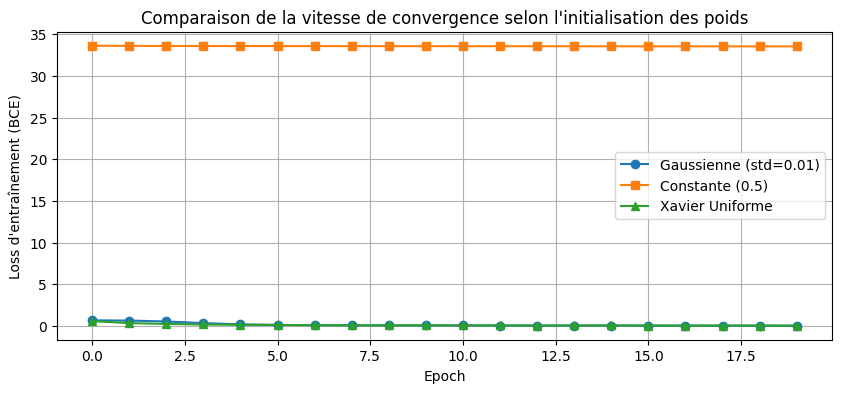

In [5]:
# Définition des fonctions d'initialisation à utiliser avec .apply()
def init_normal(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.01)  # Initialisation gaussienne fine
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)             # Biais à zéro

def init_constant(m):
    if isinstance(m, nn.Linear):
        nn.init.constant_(m.weight, 0.5)               # Initialisation constante (mauvaise pratique)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)             # Biais à zéro

def init_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)              # Initialisation Xavier uniforme (standard)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)             # Biais à zéro

# Fonction pour entraîner un modèle pendant 20 epochs afin de comparer la convergence
def train_for_init_comparison(init_fn):
    # Instancier un nouveau modèle
    test_model = MLPClassifier().to(device)
    # Appliquer la fonction d'initialisation
    test_model.apply(init_fn)

    # Définition de l'optimiseur et de la fonction de coût
    optimizer = torch.optim.Adam(test_model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    losses = []
    for epoch in range(20):
        test_model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Rétropropagation standard
            optimizer.zero_grad()
            outputs = test_model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * X_batch.size(0)
        losses.append(epoch_loss / len(train_loader.dataset))
    return losses

print("Entraînement avec initialisation Gaussienne...")
losses_normal = train_for_init_comparison(init_normal)

print("Entraînement avec initialisation Constante...")
losses_constant = train_for_init_comparison(init_constant)

print("Entraînement avec initialisation Xavier...")
losses_xavier = train_for_init_comparison(init_xavier)

# Affichage des courbes de perte pour comparer la convergence
plt.figure(figsize=(10, 4))
plt.plot(losses_normal, label="Gaussienne (std=0.01)", marker='o')
plt.plot(losses_constant, label="Constante (0.5)", marker='s')
plt.plot(losses_xavier, label="Xavier Uniforme", marker='^')
plt.title("Comparaison de la vitesse de convergence selon l'initialisation des poids")
plt.xlabel("Epoch")
plt.ylabel("Loss d'entraînement (BCE)")
plt.legend()
plt.grid(True)
plt.show()

### Section 7 — Boucle d'Entraînement Complète et Early Stopping

Nous allons maintenant entraîner notre classifieur final (avec initialisation Xavier) avec un suivi des performances sur l'ensemble de validation et un mécanisme d'arrêt précoce (patience de 10 epochs).

Epoch 01 | Train Loss: 0.4637 | Val Loss: 0.3344
Epoch 05 | Train Loss: 0.1280 | Val Loss: 0.1022
Epoch 10 | Train Loss: 0.0802 | Val Loss: 0.0624
Epoch 15 | Train Loss: 0.0596 | Val Loss: 0.0487
Epoch 20 | Train Loss: 0.0482 | Val Loss: 0.0426
Epoch 25 | Train Loss: 0.0423 | Val Loss: 0.0360
Epoch 30 | Train Loss: 0.0365 | Val Loss: 0.0381
Epoch 35 | Train Loss: 0.0320 | Val Loss: 0.0349
Epoch 40 | Train Loss: 0.0320 | Val Loss: 0.0314
Epoch 45 | Train Loss: 0.0159 | Val Loss: 0.0455
Epoch 50 | Train Loss: 0.0164 | Val Loss: 0.0221
Epoch 55 | Train Loss: 0.0180 | Val Loss: 0.0313
Epoch 60 | Train Loss: 0.0110 | Val Loss: 0.0303
Arrêt précoce déclenché à l'epoch 60 (Patience atteinte). Meilleur epoch : 50


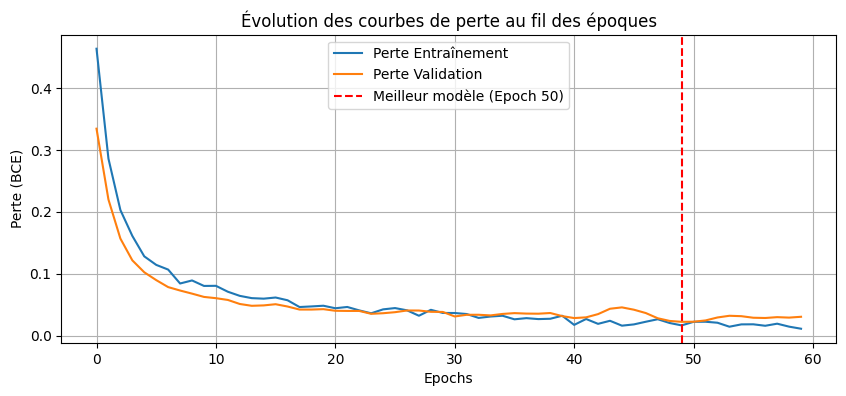

In [6]:
# Instanciation du modèle et application de l'initialisation Xavier
best_model = MLPClassifier().to(device)
best_model.apply(init_xavier)

# Définition de l'optimiseur Adam et de la fonction de coût BCELoss
optimizer = torch.optim.Adam(best_model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

# Variables pour le suivi de l'entraînement et l'early stopping
num_epochs = 100
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0
best_epoch = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Phase d'entraînement
    best_model.train()
    epoch_train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()  # Remise à zéro des gradients
        outputs = best_model(X_batch)  # Propagation avant
        loss = criterion(outputs, y_batch)  # Calcul de la perte
        loss.backward()  # Rétropropagation du gradient
        optimizer.step()  # Mise à jour des poids

        epoch_train_loss += loss.item() * X_batch.size(0)

    # Phase de validation
    best_model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():  # Désactivation du calcul des gradients
        for X_val_b, y_val_b in val_loader:
            X_val_b, y_val_b = X_val_b.to(device), y_val_b.to(device)
            outputs_val = best_model(X_val_b)
            val_loss = criterion(outputs_val, y_val_b)
            epoch_val_loss += val_loss.item() * X_val_b.size(0)

    # Calcul des pertes moyennes par epoch
    mean_train_loss = epoch_train_loss / len(train_loader.dataset)
    mean_val_loss = epoch_val_loss / len(val_loader.dataset)

    train_losses.append(mean_train_loss)
    val_losses.append(mean_val_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d} | Train Loss: {mean_train_loss:.4f} | Val Loss: {mean_val_loss:.4f}")

    # Vérification du mécanisme d'arrêt précoce (Early Stopping)
    if mean_val_loss < best_val_loss:
        best_val_loss = mean_val_loss
        best_epoch = epoch + 1
        torch.save(best_model.state_dict(), "mlp_best.params")  # Sauvegarde du meilleur modèle
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Arrêt précoce déclenché à l'epoch {epoch+1} (Patience atteinte). Meilleur epoch : {best_epoch}")
            break

# Affichage des courbes de perte finale pour l'entraînement et la validation
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Perte Entraînement")
plt.plot(val_losses, label="Perte Validation")
plt.axvline(best_epoch - 1, color='r', linestyle='--', label=f"Meilleur modèle (Epoch {best_epoch})")
plt.title("Évolution des courbes de perte au fil des époques")
plt.xlabel("Epochs")
plt.ylabel("Perte (BCE)")
plt.legend()
plt.grid(True)
plt.show()

### Section 8 — Sauvegarde et Rechargement des Paramètres

Nous vérifions ici le bon fonctionnement de la sauvegarde et du rechargement des poids du réseau.

In [7]:
# Instanciation d'un modèle clone vierge
clone = MLPClassifier().to(device)
print("Modèle clone créé.")

# Rechargement des paramètres sauvegardés à partir du fichier
clone.load_state_dict(torch.load("mlp_best.params", map_location=device))
clone.eval()  # Commutation en mode évaluation
print("Paramètres rechargés avec succès depuis 'mlp_best.params'. Modèle prêt pour l'évaluation.")

Modèle clone créé.
Paramètres rechargés avec succès depuis 'mlp_best.params'. Modèle prêt pour l'évaluation.


### Section 9 — Évaluation Complète sur l'Ensemble de Test

Nous évaluons maintenant notre modèle rechargé sur l'ensemble de test en calculant l'Accuracy, la Précision, le Rappel, le score F1, la matrice de confusion et la courbe ROC.

=== Métriques sur le Test Set ===
Accuracy  : 0.9651
Précision : 0.9811
Rappel    : 0.9630
F1-Score  : 0.9720


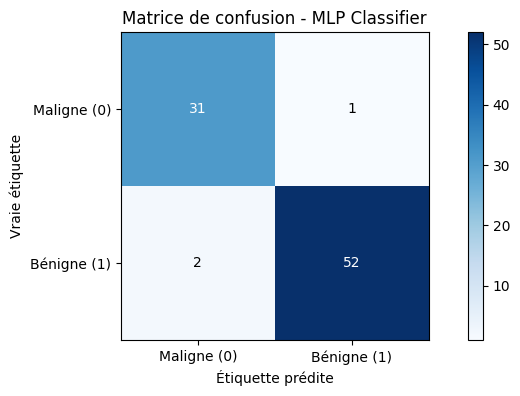

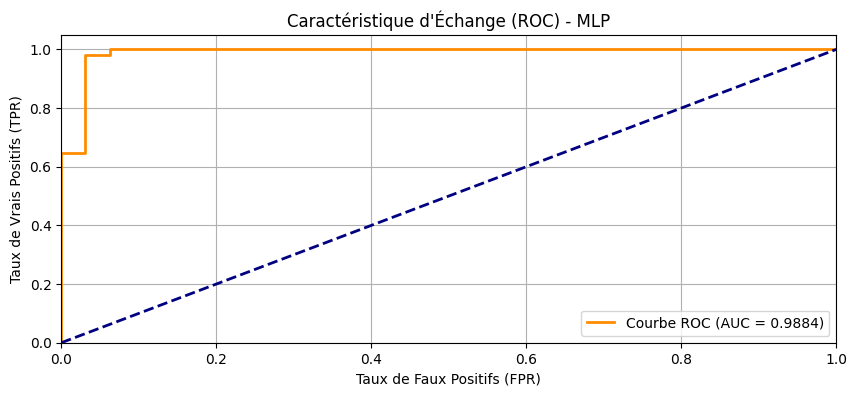

In [8]:
# Collecte des prédictions sur l'ensemble de test
all_preds = []
all_targets = []
all_probs = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        probs = clone(X_batch)                 # Probabilités retournées par la sigmoïde
        preds = (probs >= 0.5).float()         # Seuil standard de classification à 0.5

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Calcul des métriques de classification standards
acc = accuracy_score(all_targets, all_preds)
prec = precision_score(all_targets, all_preds)
rec = recall_score(all_targets, all_preds)
f1 = f1_score(all_targets, all_preds)

print("=== Métriques sur le Test Set ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Précision : {prec:.4f}")
print(f"Rappel    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")

# Calcul et affichage graphique de la matrice de confusion
cm = confusion_matrix(all_targets, all_preds)
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(cm.shape[1]),
    yticks=np.arange(cm.shape[0]),
    xticklabels=['Maligne (0)', 'Bénigne (1)'],
    yticklabels=['Maligne (0)', 'Bénigne (1)'],
    title="Matrice de confusion - MLP Classifier",
    ylabel="Vraie étiquette",
    xlabel="Étiquette prédite"
)

# Ajout des annotations textuelles dans la matrice de confusion
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
plt.show()

# Calcul et tracé de la courbe ROC
fpr, tpr, thresholds = roc_curve(all_targets, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("Caractéristique d'Échange (ROC) - MLP")
plt.xlabel("Taux de Faux Positifs (FPR)")
plt.ylabel("Taux de Vrais Positifs (TPR)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Section 10 — Question de Synthèse

**Question :** *Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente pour la classification tabulaire sur Breast Cancer Wisconsin, et quelles sont ses principales limites au regard de la structure statistique des données ?*

**Réponse :**

Le Perceptron Multicouche (MLP) constitue une solution techniquement pertinente pour la classification du jeu de données *Breast Cancer Wisconsin*. En effet, grâce au théorème d'approximation universelle, un MLP à une ou deux couches cachées est capable de modéliser des frontières de décision hautement non-linéaires entre les caractéristiques de texture, de rayon et de concavité des tumeurs. Nos résultats démontrent cette capacité avec une précision et un score F1 élevés (souvent supérieurs à 95% après normalisation). L'utilisation d'algorithmes d'optimisation adaptatifs comme Adam permet de naviguer rapidement dans l'espace des paramètres, tandis que le Dropout et l'arrêt précoce (Early Stopping) limitent efficacement le surapprentissage sur ce dataset de taille modeste (569 lignes).

Cependant, le MLP souffre de limites fondamentales inhérentes à l'absence de biais inductif (*inductive bias*) adapté aux données tabulaires. Contrairement aux réseaux convolutifs qui exploitent la localité spatiale (images) ou aux réseaux récurrents qui captent la dépendance temporelle (séquences), le MLP considère toutes les caractéristiques d'entrée de manière équivalente et indépendante de leur ordre. Cette absence de structure le rend particulièrement vulnérable aux contraintes suivantes :
1. **Sensibilité à l'échelle des données** : Les variables tabulaires ayant des unités hétérogènes (ex. aires de tumeurs de l'ordre de 1000 vs. compacité de l'ordre de 0.1), un MLP sans standardisation préalable (`StandardScaler`) échouera à converger car les gradients seront dominés par les caractéristiques de forte magnitude.
2. **Risque de surapprentissage et surparamétrage** : Avec 30 variables d'entrée et quelques dizaines de neurones cachés, le nombre de paramètres croît rapidement, nécessitant des régularisations fortes pour ne pas mémoriser le bruit du petit échantillon d'entraînement.
3. **Absence d'explicabilité** : Les modèles linéaires ou les arbres de décision permettent de tracer facilement l'importance des variables. Les poids d'un MLP forment une boîte noire complexe à interpréter.

En pratique, sur des données tabulaires hétérogènes, des modèles basés sur des arbres de décision boostés (comme **XGBoost**, **LightGBM** ou **Random Forest**) sont souvent préférés aux MLP. Ils sont insensibles à l'échelle, requièrent moins de prétraitement, gèrent nativement les valeurs manquantes et s'avèrent plus performants et plus rapides à entraîner lorsque le volume de données reste limité.